In [1]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests

from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt, quantile_transformation, zscore_transformation
from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func


%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

par = {
    'input_dir': 'input/',
    'age_groups': ['34-', '35_44', '45_54', '55_64', '65_75']
    }

genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

# Create a DataFrame for pathway annotations
pathway_assignments = []
for pathway, genes in genesets_dict.items():
    for gene in genes:
        pathway_assignments.append((gene, pathway))

pathway_df = pd.DataFrame(pathway_assignments, columns=['gene', 'pathway']).set_index('gene')


df = pd.read_csv('https://www.tau.ac.il/~elieis/HKG/HK_genes.txt', sep=' ', header=None)
housekeeping_genes = set(df.loc[:, 0])

In [2]:
major_celltypes = ['B cells',
       'CD4+ T cells', 'DN T cells', 'MAIT cells', 'Myeloid cells', 'NK cells',
       'Progenitor cells', 'TRAV1-2- CD8+ T cells', 'gd T cells']

# Cell type ratios across age groups

In [3]:
# - coexp matrix 
coexp_adata = ad.read_h5ad('output/coexp_adata_sla_spearman_False.h5ad')
coexp_adata.obs[['age_donor','sample']] =  coexp_adata.obs['age_donor'].str.rsplit('_', n=1, expand=True)

# - add cell type ratio to coexp adata obs
obs = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)

obs = obs[['Batch', 'Donor_id','Age','Cluster_names', 'Sex']]
obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

cell_type_counts = obs.groupby(['age_donor', 'cell_type']).size().unstack(fill_value=0) #TODO: shorten cell types
cell_type_ratios = cell_type_counts.div(cell_type_counts.sum(axis=1), axis=0).reset_index()

coexp_obs = coexp_adata.obs.merge(cell_type_ratios, on='age_donor', how='left')

In [70]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
coexp_obs_df = coexp_obs[major_celltypes+['age_group']].set_index('age_group')
# Assuming df is your DataFrame with age groups as index and cell types as columns
df = coexp_obs_df

# Initialize a DataFrame to store p-values and mean comparisons
p_values = pd.DataFrame(index=df.columns, columns=df.index.unique())
mean_comparisons = pd.DataFrame(index=df.columns, columns=df.index.unique())

# Loop over each age group
for age_group in df.index.unique():
    print(age_group)
    # Loop over each cell type
    for cell_type in df.columns:
        # Define the test group and the background
        test_group = df.loc[age_group, cell_type]
        background = df.loc[df.index == '34-', cell_type]
        
        # Calculate means
        mean_test = test_group.mean()
        mean_background = background.mean()

        # Perform the Mann-Whitney U test
        _, p_value = mannwhitneyu(test_group.values, background.values, alternative='two-sided')
        
        # Store the p-value and mean comparison sign
        p_values.loc[cell_type, age_group] = p_value
        if mean_test > mean_background:
            mean_comparisons.loc[cell_type, age_group] = 1  # Positive change
        elif mean_test < mean_background:
            mean_comparisons.loc[cell_type, age_group] = -1  # Negative change
        else:
            mean_comparisons.loc[cell_type, age_group] = 0  # No change

# Reset index and melt the p-values DataFrame
p_values = p_values.reset_index().melt(id_vars='index', var_name='age_group', value_name='pvalue')
mean_comparisons = mean_comparisons.reset_index().melt(id_vars='index', var_name='age_group', value_name='mean_change')

# Calculate FDR for p-values
p_values['fdr'] = multipletests(p_values['pvalue'], method='bonferroni')[1]

# Merge FDR and mean change sign
results = pd.merge(p_values, mean_comparisons, on=['index', 'age_group'])

# Combine FDR with the sign as a multiplication
results['final_fdr'] = results['fdr'] * results['mean_change']

# Pivot the final results to display FDR with signs
pivoted_results = results.pivot(index='index', columns='age_group', values='final_fdr')

# Display the pivoted results
print(pivoted_results)

65_75
55_64
45_54
35_44
34-
age_group             34-     35_44 45_54     55_64     65_75
index                                                        
B cells                 0        -1    -1 -0.789552 -0.187919
CD4+ T cells            0         1     1         1         1
DN T cells              0         1    -1        -1        -1
MAIT cells              0        -1    -1 -0.000298 -0.000033
Myeloid cells           0         1     1        -1  0.021029
NK cells                0         1    -1         1   0.14426
Progenitor cells        0         1     1         1         1
TRAV1-2- CD8+ T cells   0        -1    -1 -0.137952      -0.0
gd T cells              0 -0.046871     1  0.027871 -0.000042


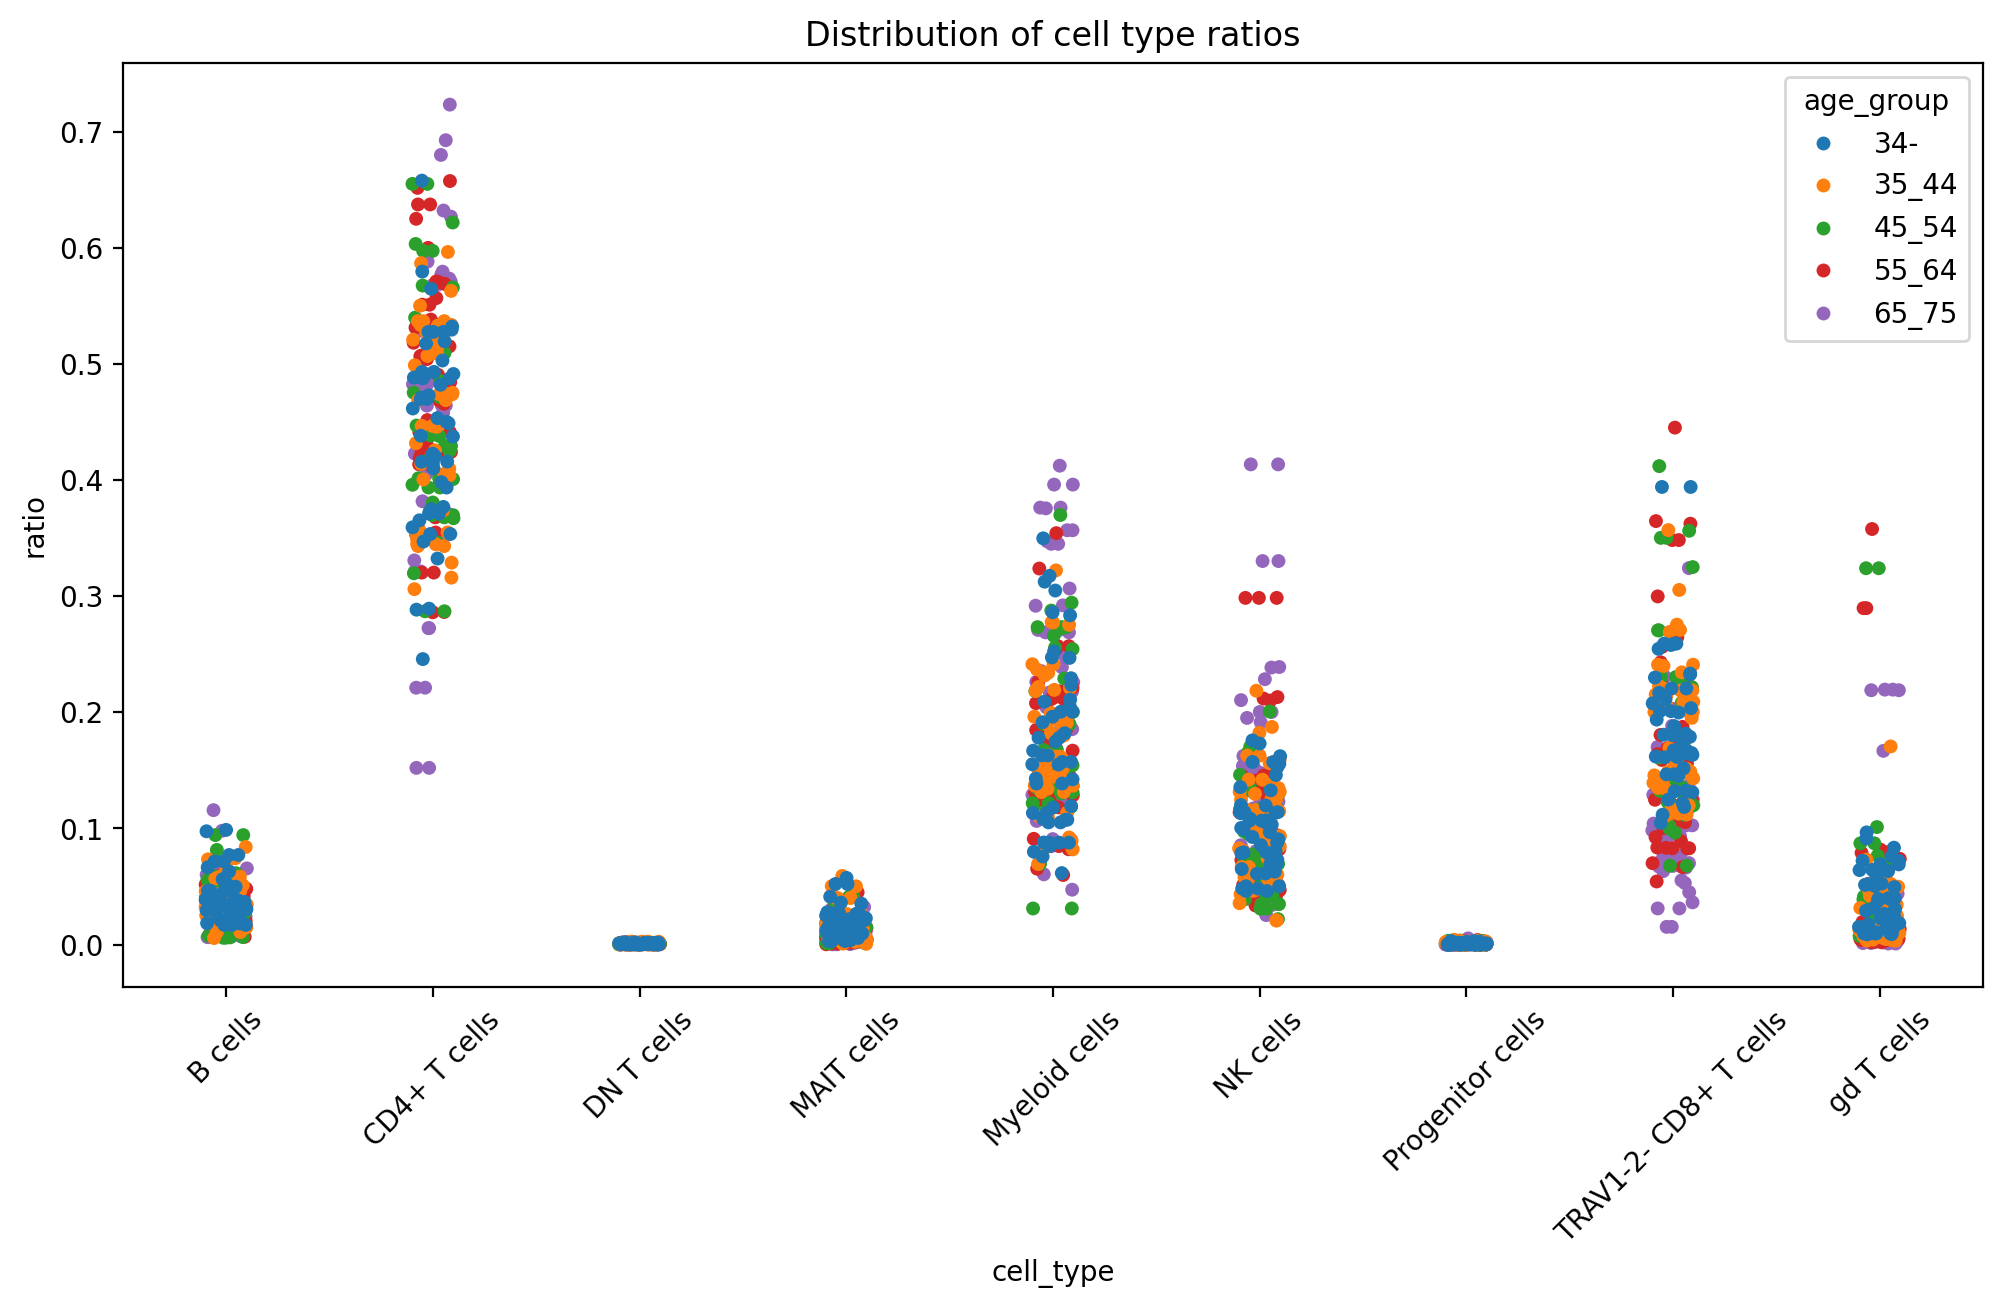

In [21]:
# Melt the DataFrame to long format for seaborn
df = coexp_obs_df
# df = df/df.max(axis=0)
df_long = df.reset_index().melt(id_vars='age_group', var_name='cell_type', value_name='ratio')

# Plot
plt.figure(figsize=(12, 6))
sns.stripplot(df_long, x='cell_type', y='ratio', hue='age_group')
plt.title('Distribution of cell type ratios')
plt.xticks(rotation=45)  # Rotate x-axis labels

plt.show()

# Feature importance

In [33]:
# - extract sig links (targets)
sig_oo = pd.read_csv('output/links_pvalues_vs_34_sla_spearman_False.csv', index_col=0)

sig_oo['bonferroni'] = multipletests(sig_oo['pvalue'], alpha=0.05, method='bonferroni')[1]
sig_oo['fdr'] = multipletests(sig_oo['pvalue'], alpha=0.05, method='fdr_bh')[1]

mask = (sig_oo['fdr']<0.05)
sig_oo = sig_oo[mask]
sig_links = sig_oo.link.unique()
print(len(sig_links))

836


In [34]:
sig_oo.age_group.value_counts()

age_group
65_75    502
45_54    357
55_64    258
35_44    158
Name: count, dtype: int64

In [35]:
target_links = np.unique(np.concatenate([np.random.choice(coexp_adata.var_names, 10000), sig_links]))

In [9]:
target_links.shape

(9898,)

In [36]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
reg_type='ridge'
# Define the input features and targets
X_df = coexp_obs[major_celltypes]
X = X_df.values

Y = coexp_adata.X[:, coexp_adata.var_names.isin(target_links)]

# Initialize K-Fold cross-validation
kf = KFold(n_splits=5, random_state=32, shuffle=True)
test_indices_per_fold = [test_index for _, test_index in kf.split(X)]

# Initialize dictionary to store results
r2_scores = {}
feature_importances = {}

# Scale features
if reg_type=='ridge':
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    model = Ridge(alpha=1)
else:
    # Set up the LightGBM model with 20 CPUs
    model = LGBMRegressor(n_jobs=20, verbose=-1,min_child_samples=5,       # Relaxing minimum child samples
        min_split_gain=0.01        # Small positive gain for flexibility in splits
    )

# Iterate over each target link
for i, target_link in enumerate(tqdm(target_links)):
    Y_i = Y[:, i]
    scores = []
    fold_importances = []

    # Perform cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = Y_i[train_index], Y_i[test_index]

        # Fit the model and predict
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate R² score for this fold
        scores.append(r2_score(y_test, y_pred))

        # Collect the feature importances for each fold
        if reg_type=='ridge':
            fold_importances.append(model.coef_)
        else:
            fold_importances.append(model.feature_importances_)

    # Store R² scores and average feature importances for this target
    r2_scores[target_link] = scores
    feature_importances[target_link] = np.mean(fold_importances, axis=0)

# Convert the results into DataFrames for easy inspection
r2_scores_df_all = pd.DataFrame(r2_scores)
r2_scores_df = r2_scores_df_all[sig_links]
feature_importances_df = pd.DataFrame(feature_importances, index=X_df.columns) 

100%|██████████| 10678/10678 [02:26<00:00, 73.04it/s]


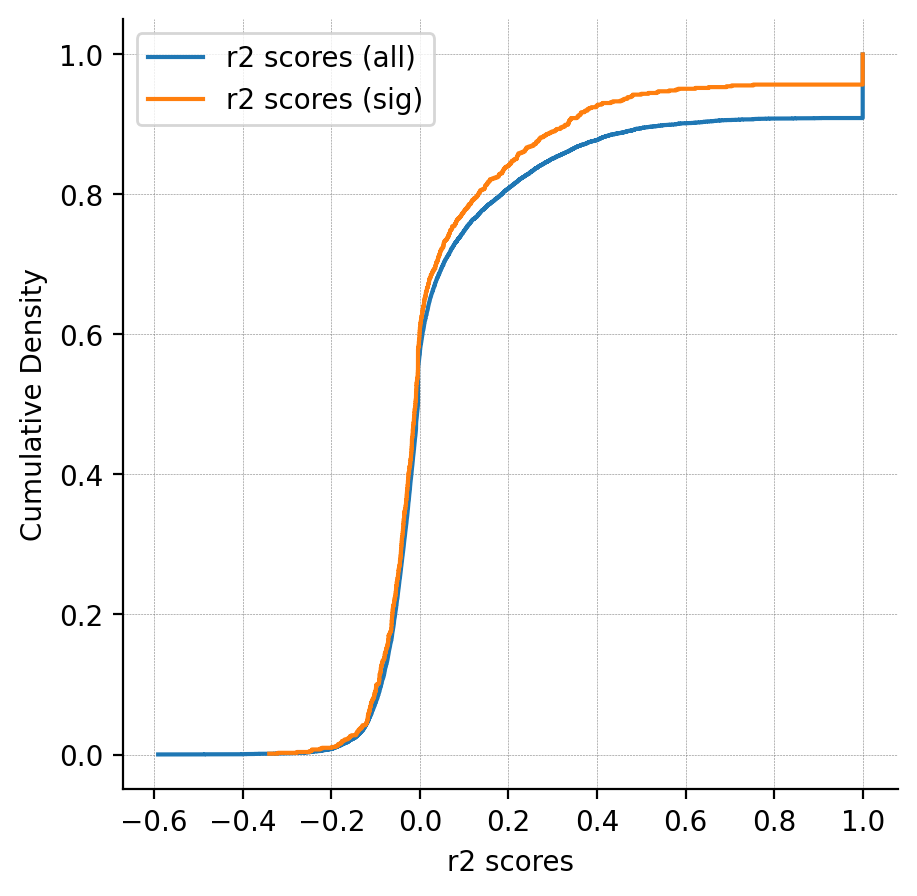

In [54]:
# - r2 scores distribution
fig, ax = plt.subplots(1,1, figsize=(5,5))
plot_cumulative_density(r2_scores_df_all.mean(axis=0), label='r2 scores (all)', ax=ax)
plot_cumulative_density(r2_scores_df.mean(axis=0), label='r2 scores (sig)', ax=ax)

plt.xlabel('r2 scores')
plt.legend()

In [49]:
# - percentile rank of sig link vs remaining
scores_rand = []
for i in range(100):
    rand_cols = np.random.choice(r2_scores_df_all.columns, len(sig_links))
    scores_rand.append(r2_scores_df_all[rand_cols].mean(axis=0).mean())
sig_score = r2_scores_df.mean(axis=0).mean()
(scores_rand < sig_score).sum()

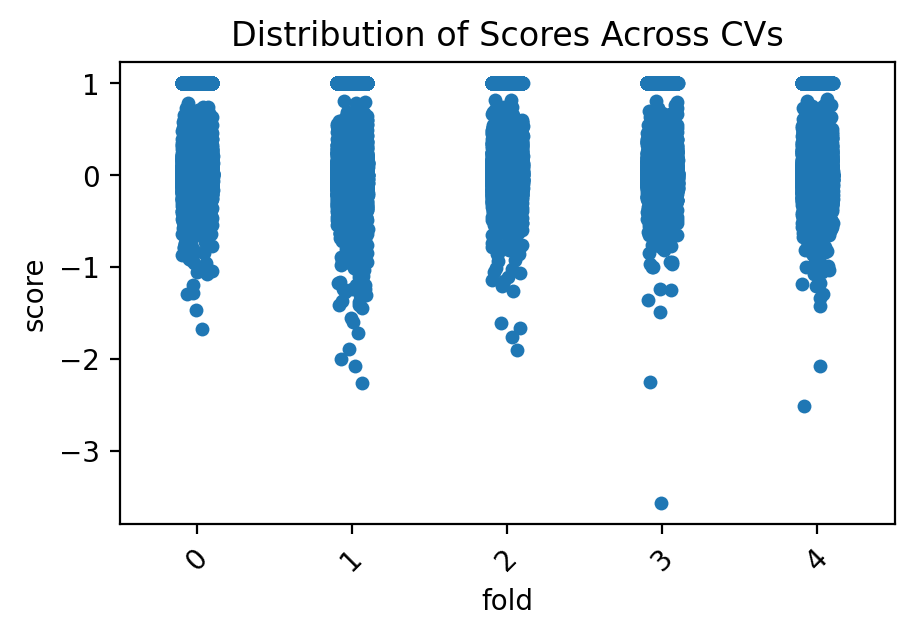

In [14]:
# - r2 scores across cvs 
r2_scores_long = r2_scores_df.reset_index().melt(id_vars='index', var_name='link', value_name='score').rename(columns={'index':'fold'})

plt.figure(figsize=(5, 3))
sns.stripplot(data=r2_scores_long, x='fold', y='score')
plt.xticks(rotation=45)
plt.title("Distribution of Scores Across CVs")
plt.show()

In [55]:
# - identify those links with low r2 scores -> generic links
low_scored_links = r2_scores_df.loc[:, r2_scores_df.mean()<0].columns
sig_oo[sig_oo.link.isin(low_scored_links)]

,link,age_group,pvalue,mean,median,mean_ctr,mean_median,diff_median,diff,bonferroni,fdr
29,CD83_LCK,55_64,0.004656,-0.246812,-0.248452,-0.285189,-0.291517,0.043065,0.038377,1.0,0.042247
30,CD83_LCK,45_54,0.000442,-0.241045,-0.232407,-0.285189,-0.291517,0.059110,0.044144,1.0,0.012099
33,HLA-DRA_LCK,55_64,0.004757,-0.311571,-0.311664,-0.352656,-0.351097,0.039433,0.041085,1.0,0.042518
45,HLA-DMA_LCK,55_64,0.000255,-0.188143,-0.180032,-0.222436,-0.224604,0.044571,0.034293,1.0,0.009272
82,LCK_MAP3K8,45_54,0.001696,-0.122049,-0.126999,-0.147385,-0.148341,0.021343,0.025336,1.0,0.023749
...,...,...,...,...,...,...,...,...,...,...,...
10067,CFP_FKBP1A,35_44,0.001910,0.200786,0.204330,0.172055,0.164204,0.040126,0.028730,1.0,0.025206
10080,CEBPB_CFP,65_75,0.004966,0.246112,0.239625,0.201366,0.191603,0.048022,0.044746,1.0,0.043687
10083,CEBPB_CFP,35_44,0.001737,0.236726,0.244615,0.201366,0.191603,0.053012,0.035360,1.0,0.023972
10100,CFP_SAT1,65_75,0.000217,0.437969,0.457952,0.376384,0.384052,0.073900,0.061585,1.0,0.008838


In [68]:
# - keep high predicted links and check the feature importance 
r2score_t = .2

high_predicted_links = r2_scores_df.loc[:, r2_scores_df.mean()>r2score_t].columns
feature_importances_df_f = feature_importances_df[high_predicted_links]
feature_importances_df_n = (feature_importances_df_f/feature_importances_df_f.abs().max(axis=0)).fillna(1)
feature_importances_df_n

,HLA-DRB1_LCK,HLA-DPA1_LCK,ATP6V0B_NUMB,PTPRE_TXNIP,CTSS_RALB,CTSS_LEF1,CCND3_CTSS,B2M_CTSS,CTSS_GRB2,CTSS_RAB31,...,B2M_IFI30,B2M_SAT1,COX4I1_RPL36,COX4I1_RPL18,FCGRT_RAB31,FKBP1A_RAB31,RAB31_SAT1,ITGB2_RPL36,CEBPB_IFI30,FCGRT_SAT1
B cells,0.162215,-0.338018,-0.169185,1.0,-0.417052,0.090184,0.243153,-0.768218,-0.075489,-0.950844,...,-0.176975,0.229580,0.218628,0.204920,0.391742,-0.084610,1.0,1.0,-0.272659,-0.011270
CD4+ T cells,0.521360,-0.318963,-0.146405,1.0,-0.325446,1.000000,-0.185022,0.137632,-0.302670,-0.532033,...,-0.138110,0.142772,-0.834266,-0.810827,-0.118556,0.044156,1.0,1.0,-0.358704,0.110981
DN T cells,0.150587,0.103468,0.270337,1.0,0.131055,-0.099926,-0.106727,0.200877,-0.209603,0.453164,...,0.082360,0.066504,-0.028032,-0.013271,0.010480,0.009827,1.0,1.0,0.100171,-0.203650
MAIT cells,-0.271341,0.016099,-0.102941,1.0,-0.014955,0.179931,-0.052569,-0.039333,-0.137000,-0.247012,...,-0.055378,-0.123358,-0.385625,-0.617363,-0.109345,0.129305,1.0,1.0,0.077318,0.059988
Myeloid cells,-0.632763,1.000000,1.000000,1.0,1.000000,-0.726169,1.000000,1.000000,-0.749436,1.000000,...,1.000000,-1.000000,-0.173091,0.334029,-0.866260,-0.478769,1.0,1.0,1.000000,1.000000
NK cells,-1.000000,-0.461097,-0.263456,1.0,-0.473743,-0.458434,-0.481551,-0.490819,0.556070,-0.219264,...,-0.378670,-0.312116,0.851706,0.407516,-0.669359,1.000000,1.0,1.0,0.013913,-0.913716
Progenitor cells,0.950729,-0.024628,0.156562,1.0,-0.018866,0.660374,0.595855,0.199089,1.000000,-0.626764,...,0.090359,0.606380,-1.000000,-1.000000,0.730137,-0.636504,1.0,1.0,-0.788146,-0.263317
TRAV1-2- CD8+ T cells,0.658843,-0.148564,-0.363218,1.0,-0.101358,-0.201434,-0.164948,-0.369619,0.414982,0.096908,...,-0.294962,0.808820,0.414086,0.426768,1.000000,-0.008715,1.0,1.0,-0.464966,-0.481968
gd T cells,0.137318,-0.008026,-0.272419,1.0,-0.013677,-0.044242,-0.401433,-0.314903,0.439757,0.043285,...,-0.259471,0.305681,0.225751,-0.000777,0.646549,-0.485388,1.0,1.0,-0.045684,0.075679


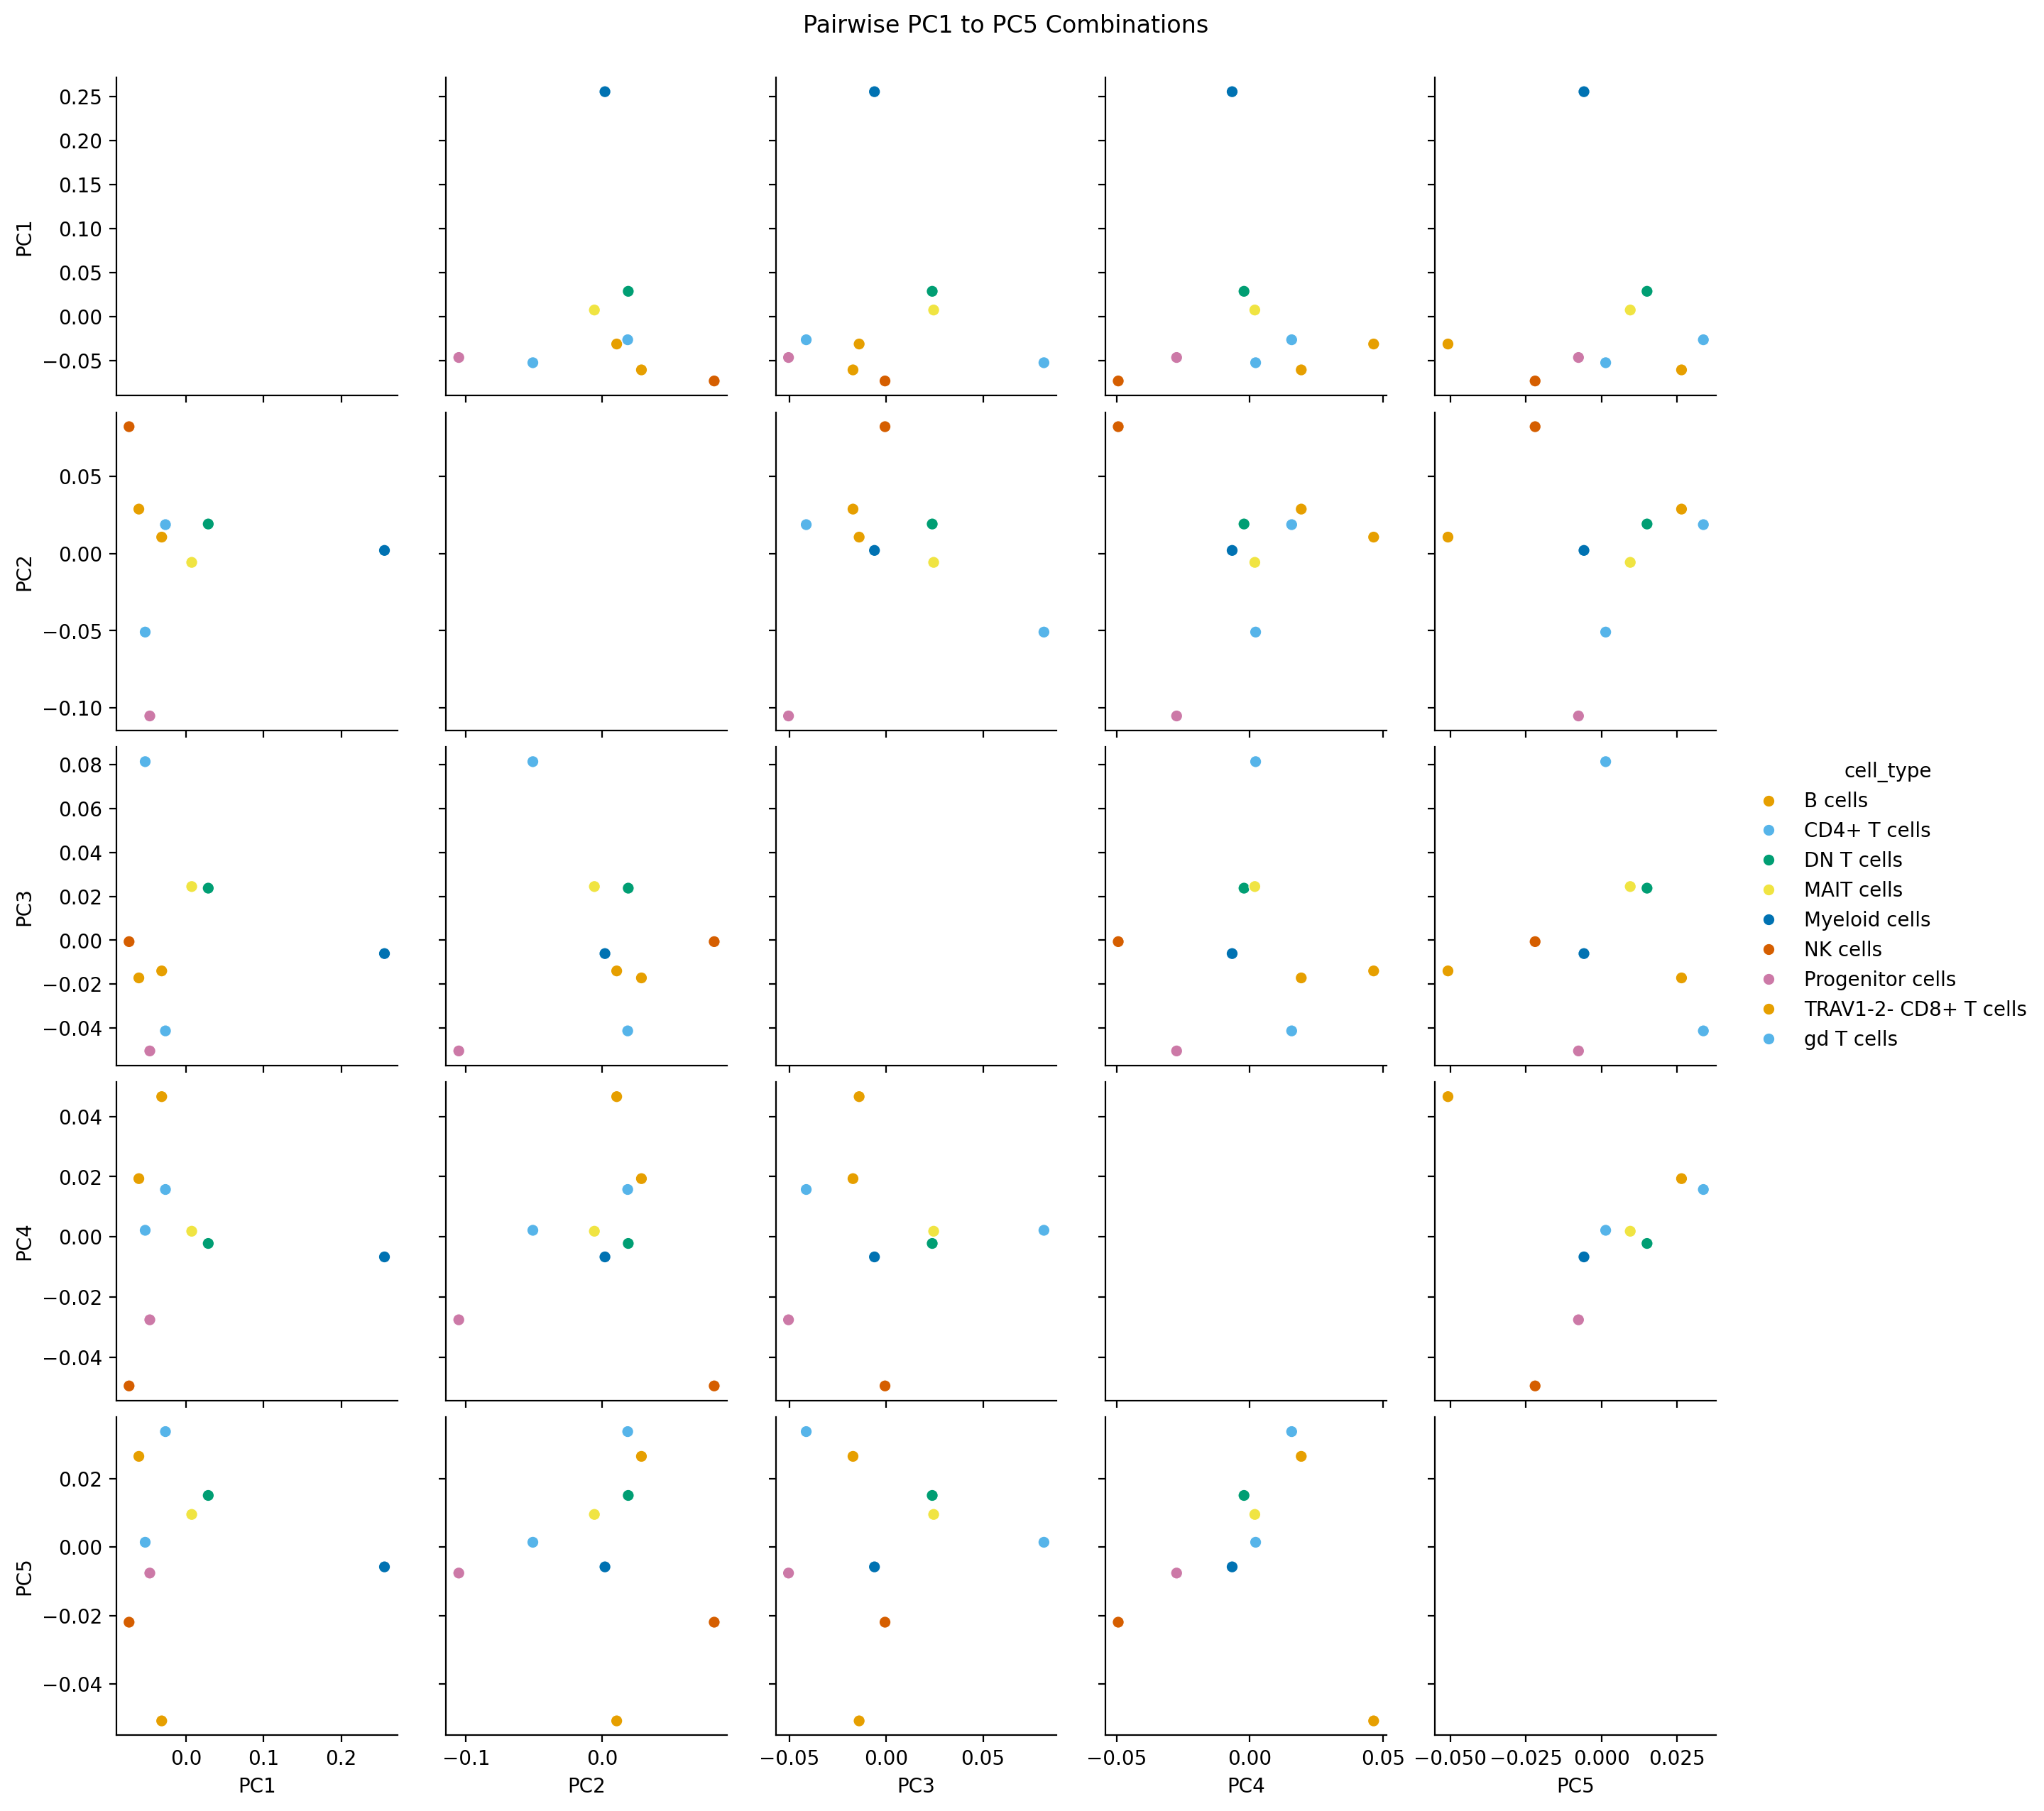

In [69]:
# - PCA analysis of feature importance
adata_feature_importance = ad.AnnData(feature_importances_df_f)
sc.pp.pca(adata_feature_importance, n_comps=5)

pca_df = pd.DataFrame(adata_feature_importance.obsm['X_pca'], columns=[f'PC{i+1}' for i in range(5)])

# Add age_group to the DataFrame
pca_df['cell_type'] = adata_feature_importance.obs.index
# Create pairplot of all combinations of PC1 to PC6, colored by age_group
sns.pairplot(pca_df, hue='cell_type', palette=colors_blind)  # You can choose any palette you prefer
plt.suptitle("Pairwise PC1 to PC5 Combinations", y=1.02)
plt.show()

In [77]:
# - analysis of loadings
pc_loadings = pd.DataFrame({'share':adata_feature_importance.varm['PCs'][:, 0]}, index= adata_feature_importance.var_names)
pc_loadings.index.name = 'link'
pc_loadings = pc_loadings.sort_values(by='share', ascending=False, key=abs)


In [78]:
# - subset feature importanc to those high loadings
associated_links = pc_loadings.iloc[:20,].index
feature_importances_df_n_pc1 = feature_importances_df_n[associated_links]
feature_importances_df_n_pc1

link,B2M_STOM,HLA-DRB1_LEF1,B2M_PTEN,FCGRT_TCIRG1,HINT1_IFI30,B2M_RAB31,ACTR2_RPS12,HLA-DRA_SAT1,DGKA_HLA-DRB1,DGKA_IFI30,B2M_MARCKS,HLA-DRA_RPSA,CCND3_CTSS,B2M_IFI30,FCN1_HLA-A,HINT1_MARCKS,FCGRT_SAT1,FOSL2_PLEK,CTSS_SAT1,HINT1_LEF1
B cells,0.084393,-0.153311,0.142551,-0.141312,-0.213307,0.161643,0.012023,0.069013,-0.244237,-0.061733,-0.594722,-0.113878,0.243153,-0.176975,0.234776,-0.208433,-0.011270,-0.277762,0.222413,0.198230
CD4+ T cells,-0.504232,-0.403210,0.192093,-0.075523,-0.286806,0.006465,0.050127,-0.384699,-0.511271,-0.358971,-0.430988,-0.564922,-0.185022,-0.138110,0.146940,-0.379752,0.110981,-0.013129,0.482193,-0.114304
DN T cells,-0.082345,0.131077,-0.191861,-0.054235,0.035569,-0.039099,0.019453,0.347733,0.112200,-0.057299,0.088999,0.116242,-0.106727,0.082360,-0.144478,0.056961,-0.203650,0.146445,-0.206975,-0.065119
MAIT cells,-0.019119,-0.008336,-0.084376,0.006540,0.071070,0.003508,0.086214,0.082250,-0.088045,-0.071523,-0.003932,-0.179837,-0.052569,-0.055378,0.066078,0.074918,0.059988,-0.049174,0.027180,-0.181292
Myeloid cells,1.000000,1.000000,-1.000000,1.000000,1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000
NK cells,-0.452081,-0.191288,0.434729,-0.566938,-0.303089,0.219978,0.459881,-0.227709,-0.235088,-0.134464,0.370654,-0.122760,-0.481551,-0.378670,0.246362,-0.262082,-0.913716,-0.523855,0.131300,0.625544
Progenitor cells,0.172513,-0.114573,0.392291,-0.030608,-0.065031,0.577318,0.536311,-0.374493,-0.400822,-0.482176,-0.574257,-0.181677,0.595855,0.090359,-0.431990,-0.179059,-0.263317,0.229312,0.740760,-0.061963
TRAV1-2- CD8+ T cells,-0.088484,-0.231614,0.291189,-0.403241,-0.282171,0.432733,0.357488,-0.325060,-0.164973,-0.349627,-0.230260,-0.189816,-0.164948,-0.294962,0.273743,-0.266979,-0.481968,-0.367795,0.094823,0.399893
gd T cells,0.081551,-0.100871,0.142738,-0.034157,-0.108758,0.481366,0.279298,-0.060177,0.101044,-0.088665,-0.509717,0.076118,-0.401433,-0.259471,0.403014,-0.011429,0.075679,-0.187138,0.179294,0.330761


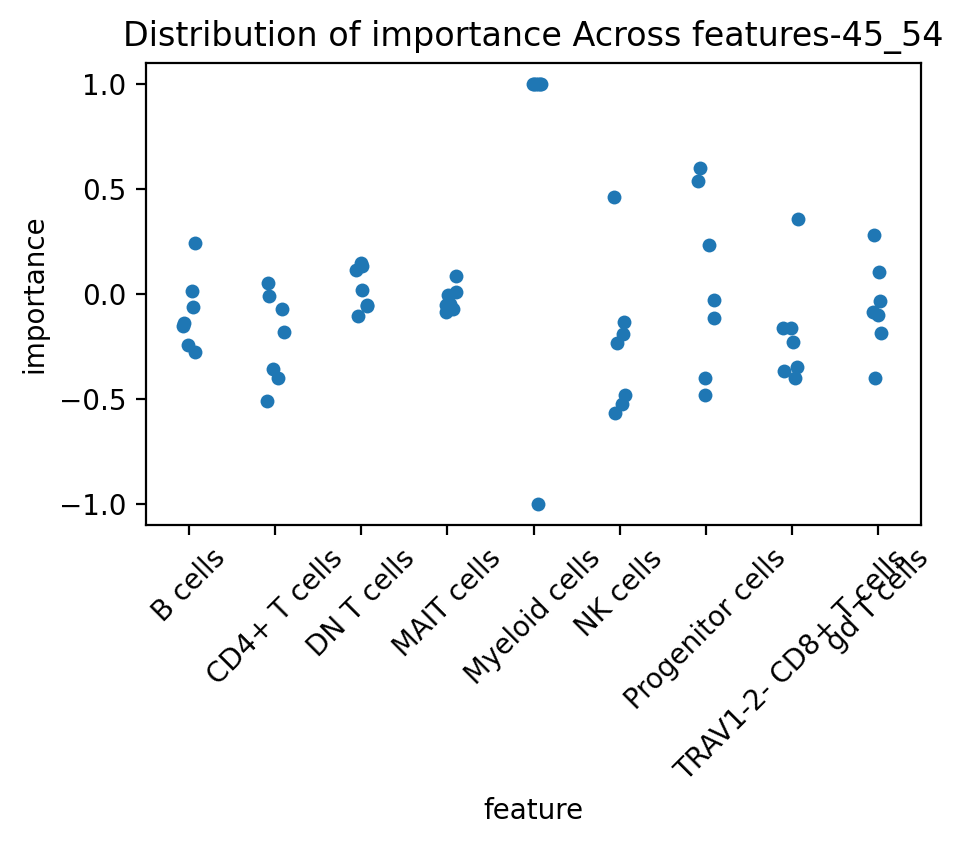

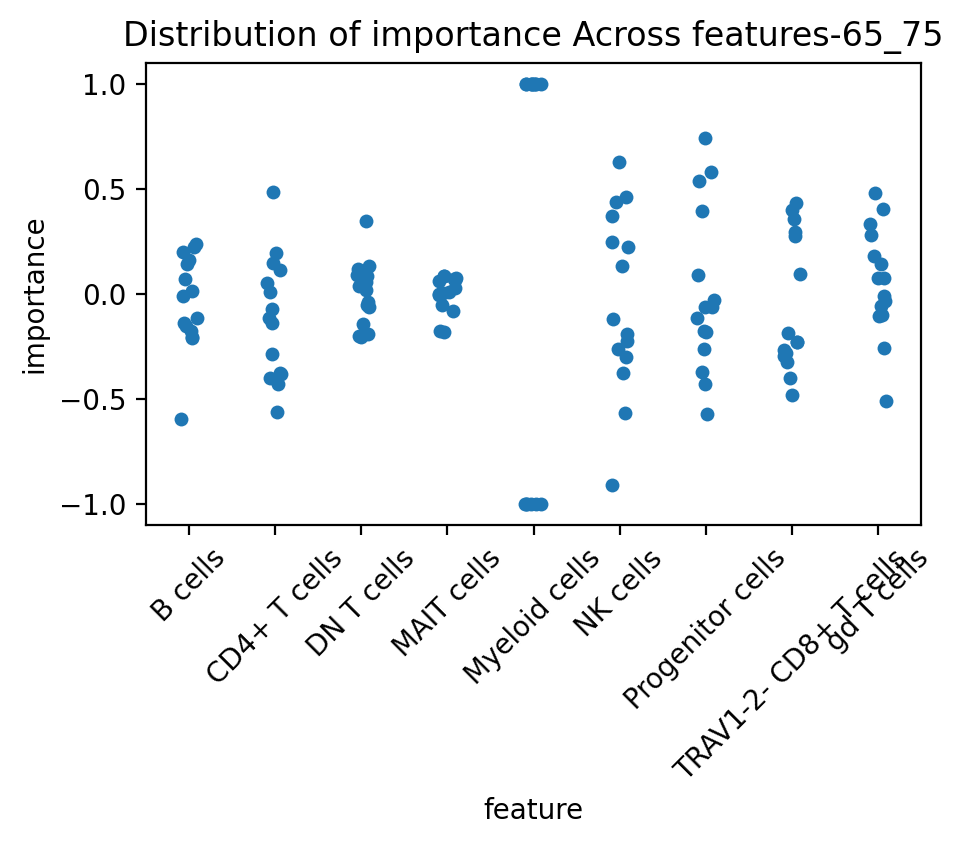

In [80]:
feature_importances_long = feature_importances_df_n_pc1.reset_index().melt(id_vars='index', var_name='link', value_name='importance').rename(columns={'index':'feature'})

for age_group in ['45_54','65_75']:
    feature_importances_long_f = feature_importances_long[feature_importances_long.link.isin(sig_oo[sig_oo.age_group==age_group].link)]
    # feature_importances_long_f = feature_importances_long
    plt.figure(figsize=(5, 3))
    sns.stripplot(data=feature_importances_long_f, x='feature', y='importance')
    plt.xticks(rotation=45)
    plt.title(f"Distribution of importance Across features-{age_group}")
    plt.show()